# GAM forecasting on the same finance sample as VAR

This notebook uses the same weekly stock CSV as the VAR notebook, but reframes it as a one-target regression problem. It does four concrete things:

1. It builds a lagged feature table from the finance sample in `data/`.
2. It tunes a spline GAM on an earlier validation block.
3. It compares that model to a flat baseline and a VAR reference on the last 12 weeks.
4. It visualizes both the forecast path and the smooth feature effects, then saves all figures and tables to `out/`.

The goal is not to claim that GAMs are universally better for finance. The point is to show how the same stock data can be viewed either as a multivariate time-series problem or as an additive regression problem with lagged predictors.


In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd()
while not (ROOT / "xai_book").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

DATA_DIR = Path("data")
NOTEBOOK_SLUG = "gam_finance_forecasting"
OUT_DIR = Path("out") / NOTEBOOK_SLUG
OUT_DIR.mkdir(parents=True, exist_ok=True)


def out_path(filename: str) -> Path:
    return OUT_DIR / filename


def save_table(frame, filename: str) -> Path:
    path = out_path(filename)
    path.parent.mkdir(parents=True, exist_ok=True)
    frame.to_csv(path)
    print(f"saved: {path}")
    return path


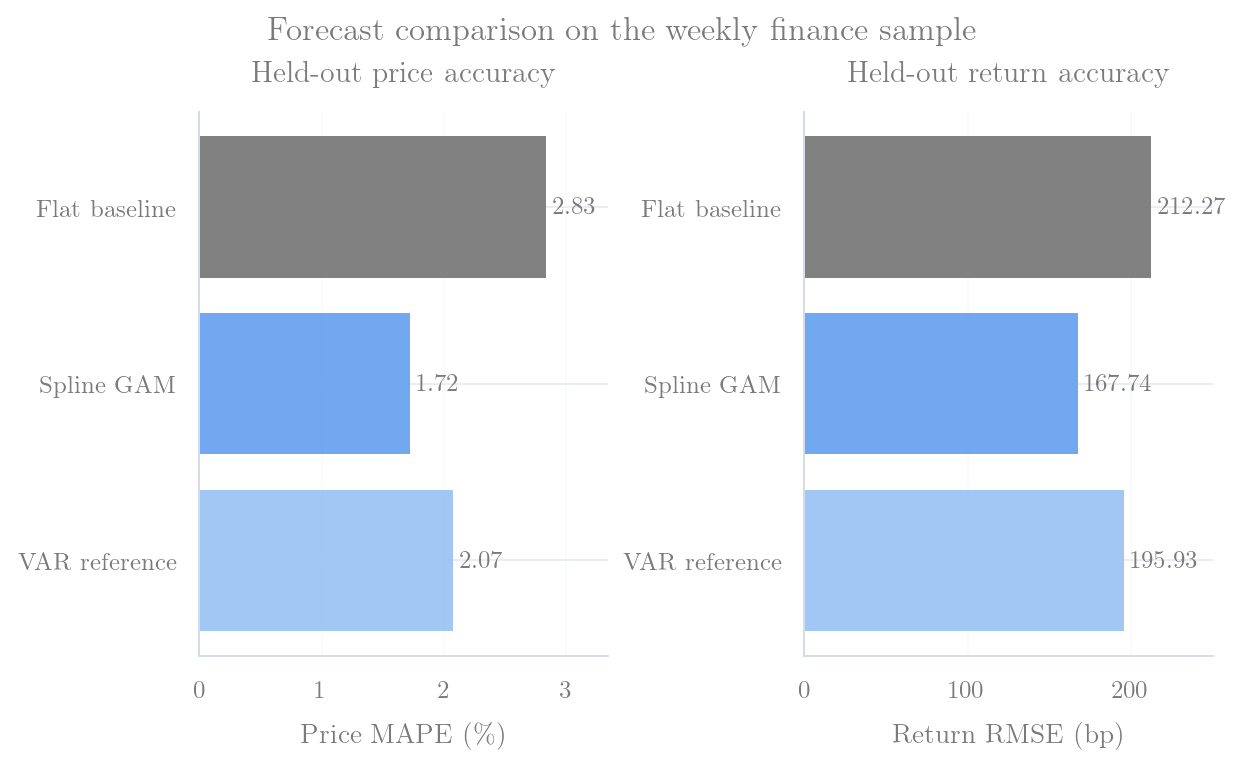

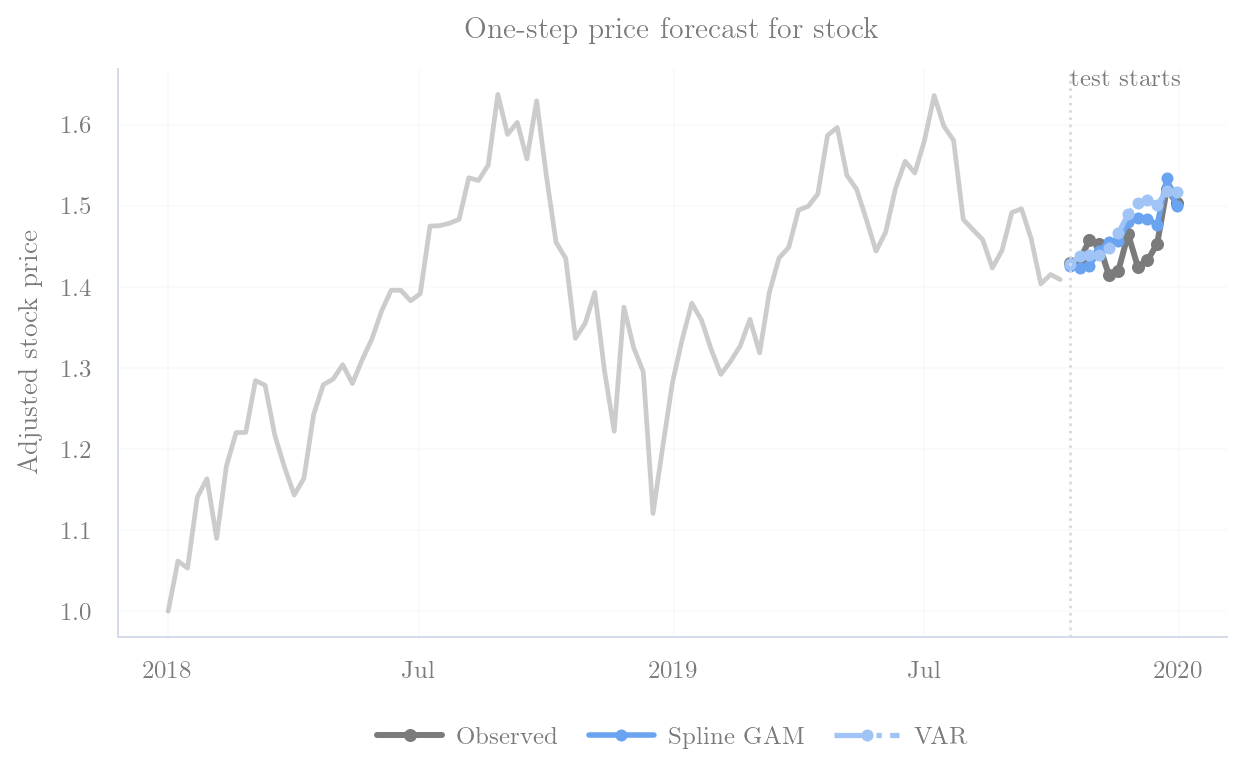

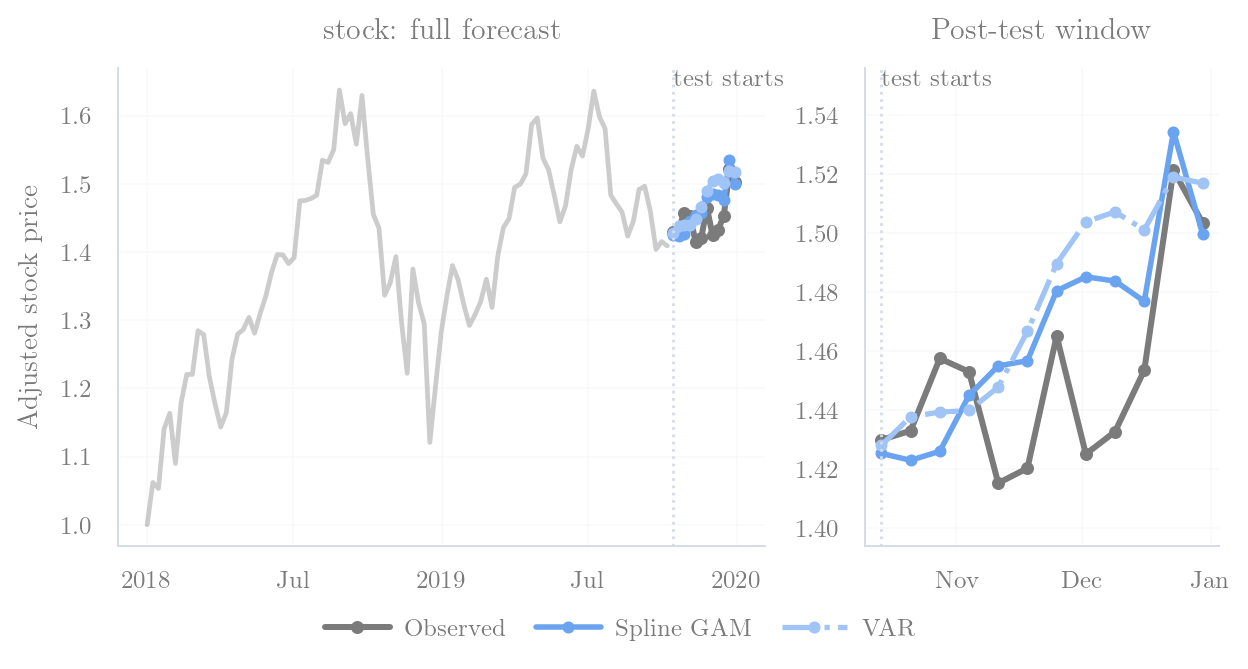

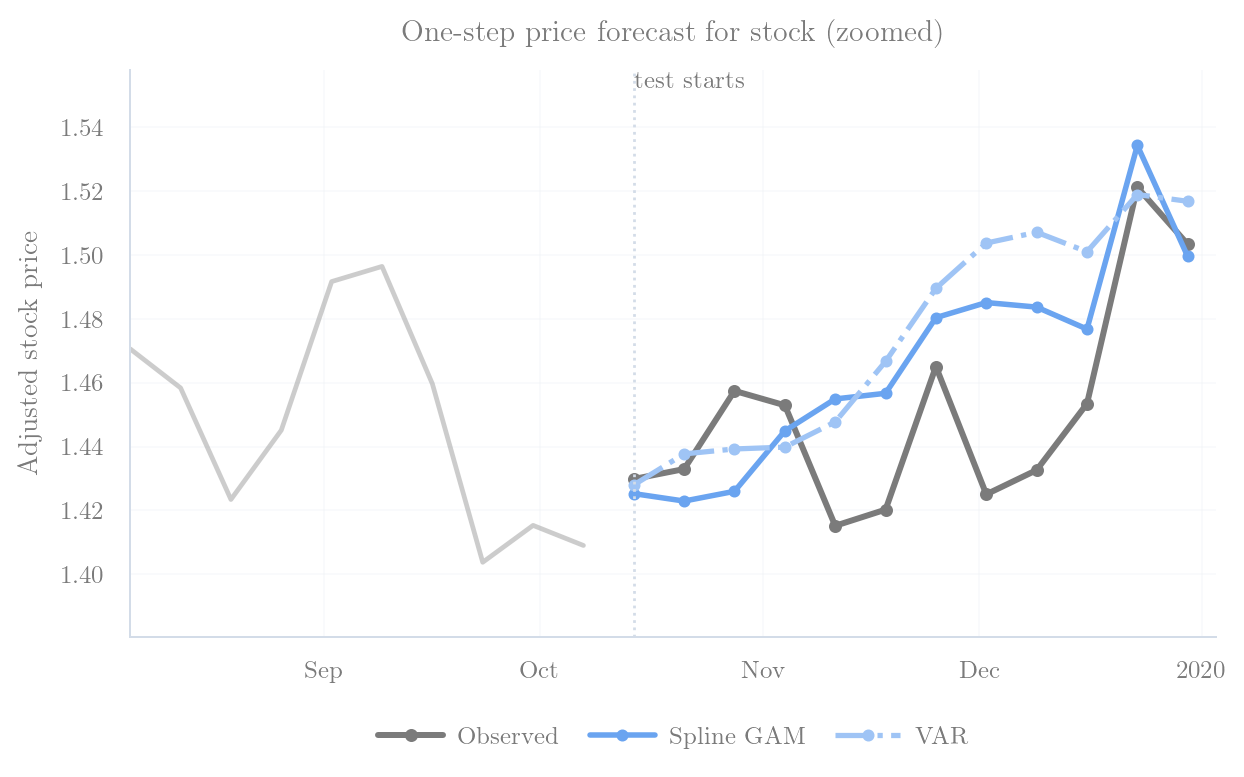

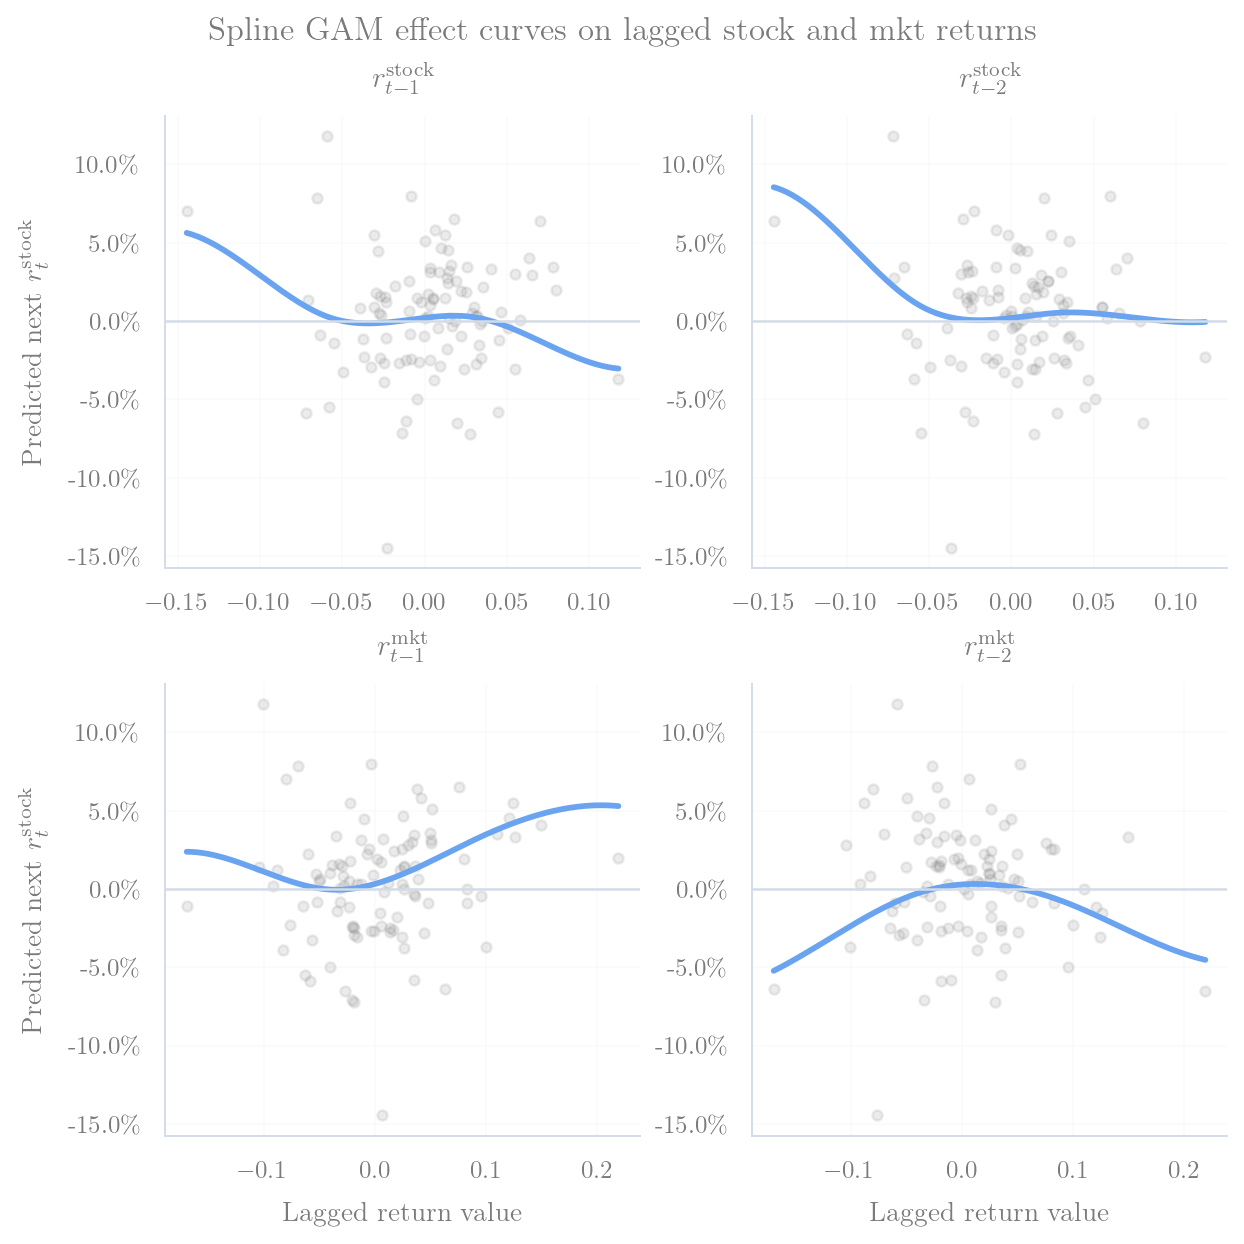

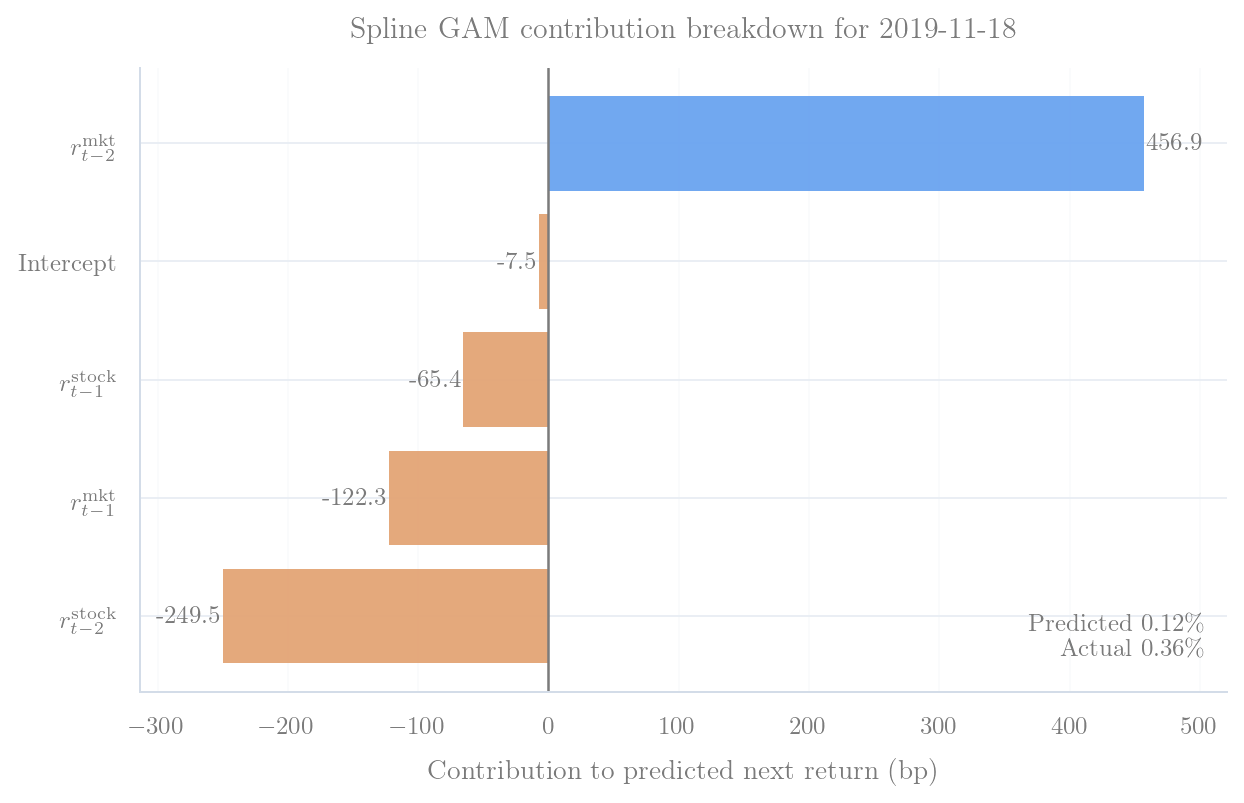

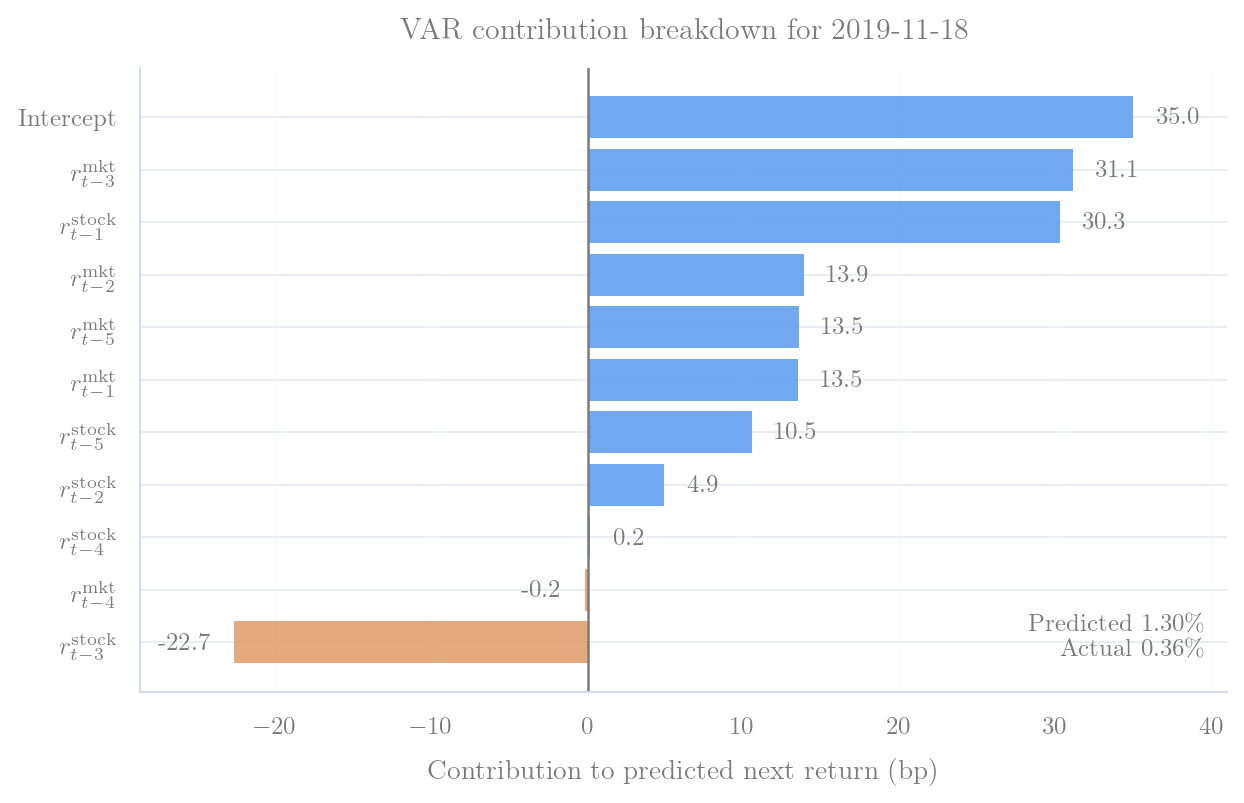

In [2]:
from IPython.display import display
import pandas as pd

from xai_book.gam_finance_models import (
    DEFAULT_FINANCE_GAM_PEER,
    DEFAULT_FINANCE_GAM_TARGET,
    FINANCE_GAM_FIGURE_FILENAMES,
    FINANCE_GAM_MODEL_LABELS,
    FINANCE_GAM_TABLE_FILENAMES,
    run_finance_gam_analysis,
)
from xai_book.plotting import display_and_save_figure

DATA_PATH = DATA_DIR / "finance_var_sample_stocks.csv"
TARGET = DEFAULT_FINANCE_GAM_TARGET
PEER = DEFAULT_FINANCE_GAM_PEER
analysis = run_finance_gam_analysis(data_path=DATA_PATH, target=TARGET, peer=PEER)

metrics = analysis["metrics"].set_index("model").round(3)
search_table = analysis["search"].copy()
search_summary = pd.DataFrame(
    {
        "model": [FINANCE_GAM_MODEL_LABELS["gam"]],
        "selected_alpha": [analysis["gam_best"]["alpha"]],
        "selected_n_knots": [int(analysis["gam_best"]["n_knots"])],
        "validation_price_MAPE_pct": [analysis["gam_best"]["validation_price_MAPE_pct"]],
    }
).set_index("model").round(3)
gam_breakdown_table = analysis["gam_breakdown_frame"][["term", "contribution"]].set_index("term").round(6)
var_breakdown_table = analysis["var_breakdown_frame"][["term", "contribution"]].set_index("term").round(6)


def show_and_save(name: str) -> Path:
    path = display_and_save_figure(
        analysis["figures"][name],
        out_path(f"{FINANCE_GAM_FIGURE_FILENAMES[name]}.pdf"),
    )
    print(f"saved: {path}")
    return path


## 1. Task And Feature Design

This notebook uses the same finance sample as the VAR notebook, but forecasts one series at a time. In the lecture-note notation, the response is the next weekly $r_t^{\mathrm{stock}}$ and the predictors are the four lagged returns $r_{t-1}^{\mathrm{stock}}, r_{t-2}^{\mathrm{stock}}, r_{t-1}^{\mathrm{mkt}}, r_{t-2}^{\mathrm{mkt}}$.

The actual CSV still supplies two observed series under the hood, but the figures use the symbolic names `stock` and `mkt` so the notation matches the text.

That keeps the comparison clean:

- VAR sees a multivariate return process.
- The spline GAM sees the same lagged feature vector, but allows each return lag to have its own smooth nonlinear effect.


In [3]:
setup_frame = pd.Series(
    {
        "data_path": str(DATA_PATH),
        "stock_symbol": analysis["series_labels"][TARGET],
        "mkt_symbol": analysis["series_labels"][PEER],
        "stock_series": TARGET,
        "mkt_series": PEER,
        "rows": len(analysis["dataset"]),
        "train_rows": len(analysis["train_full"]),
        "test_rows": len(analysis["test"]),
    },
    name="value",
).to_frame()

model_frame = pd.DataFrame(
    {
        "component": [
            "Target",
            "Features",
            "Flat baseline",
            "Spline GAM",
            "VAR reference",
        ],
        "description": [
            "Next weekly stock log return",
            "Lagged stock and mkt returns at t-1 and t-2",
            "Predict the last observed training price forward with zero return each week",
            "Spline GAM with one smooth term per lagged feature and ridge regularization",
            "Rolling one-step VAR forecast on the same two-series system",
        ],
    }
)

display(setup_frame)
display(model_frame)
display(search_summary)


,value
data_path,data/finance_var_sample_stocks.csv
stock_symbol,stock
mkt_symbol,mkt
stock_series,AMZN
mkt_series,NFLX
rows,102
train_rows,90
test_rows,12


,component,description
0,Target,Next weekly stock log return
1,Features,Lagged stock and mkt returns at t-1 and t-2
2,Flat baseline,Predict the last observed training price forwa...
3,Spline GAM,Spline GAM with one smooth term per lagged fea...
4,VAR reference,Rolling one-step VAR forecast on the same two-...


,selected_alpha,selected_n_knots,validation_price_MAPE_pct
model,,,
Spline GAM,0.1,4,2.074


## 2. Held-Out Forecast Comparison

The metric panel below keeps two views of performance visible at the same time:

- **Price MAPE** tells you how close the implied price path stays to the observed one.
- **Return RMSE** tells you how noisy the one-step return forecasts are.

On this sample, the spline GAM is competitive because it lowers return error and stays close to the best price-level forecast.


,price_MAE,price_RMSE,price_MAPE_pct,return_RMSE_bp,return_MAE_bp
model,,,,,
Flat baseline,0.042,0.052,2.833,212.271,168.894
Spline GAM,0.025,0.031,1.721,167.736,136.109
VAR reference,0.030,0.039,2.075,195.926,154.089


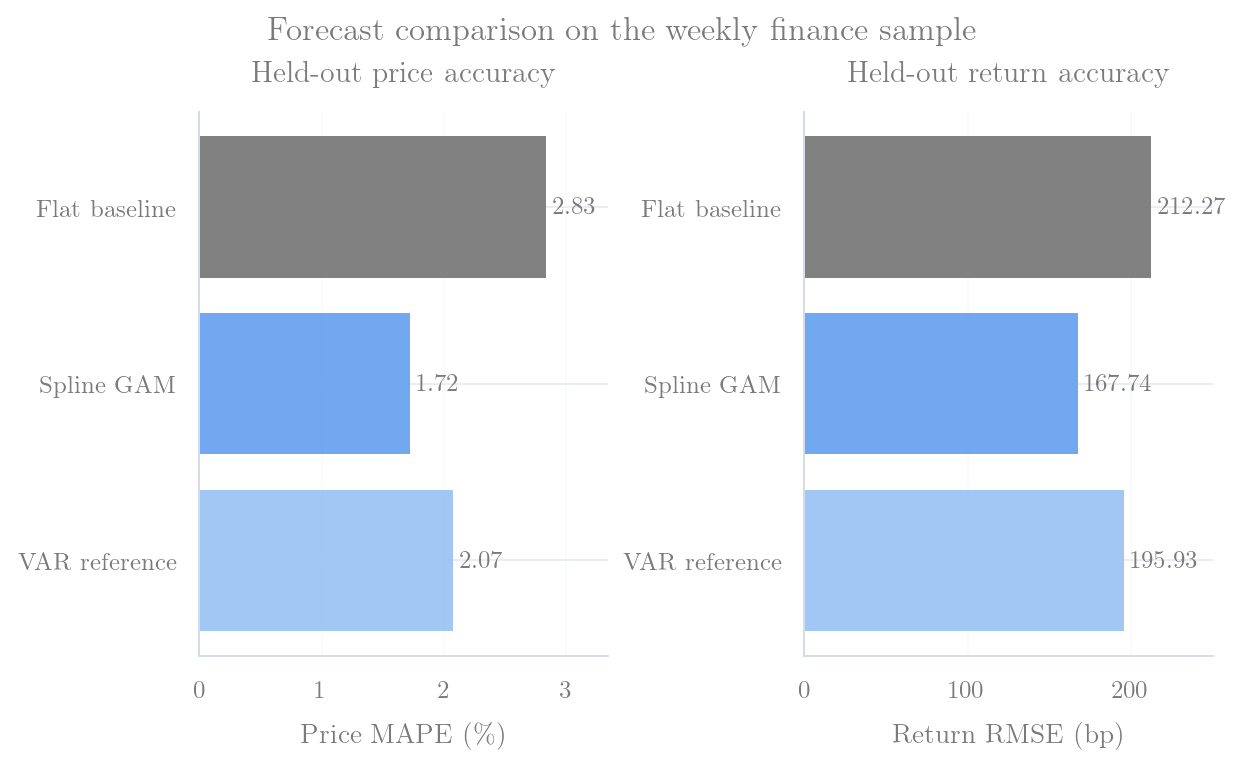

saved: out/gam_finance_forecasting/gam_finance_model_comparison.pdf


PosixPath('out/gam_finance_forecasting/gam_finance_model_comparison.pdf')

In [4]:
display(metrics)
show_and_save("model_comparison")


## 3. Forecasted Price Path

This plot makes the setup parallel to the VAR notebook: the history is shown up to the forecast cutoff, then the true next prices are overlaid with the one-step-ahead predictions from the spline GAM and the VAR reference.


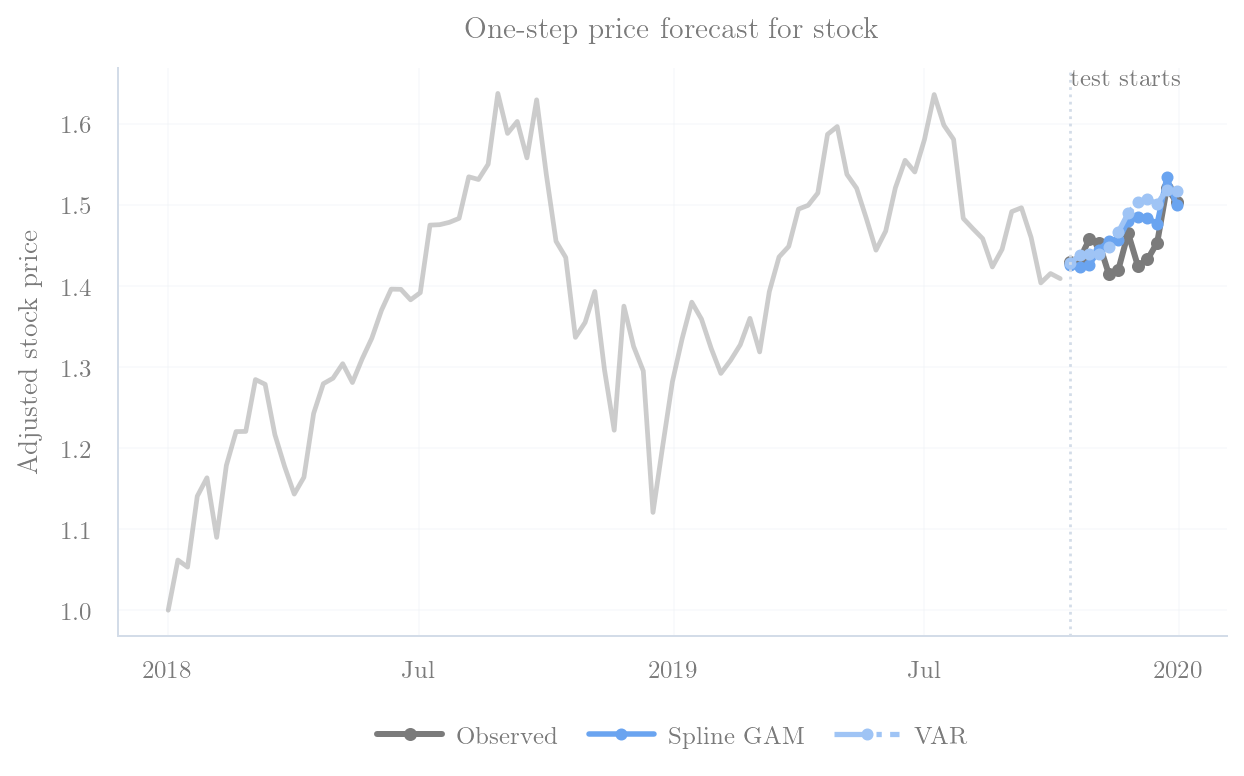

saved: out/gam_finance_forecasting/gam_finance_forecast.pdf


PosixPath('out/gam_finance_forecasting/gam_finance_forecast.pdf')

In [5]:
show_and_save("forecast")


## 4. Full Forecast With Post-Test Zoom

This export places the full held-out forecast next to a second panel that keeps only the part after the test period starts. It is useful when the lecture notes need one figure with both the overall context and the local comparison in the forecast window.


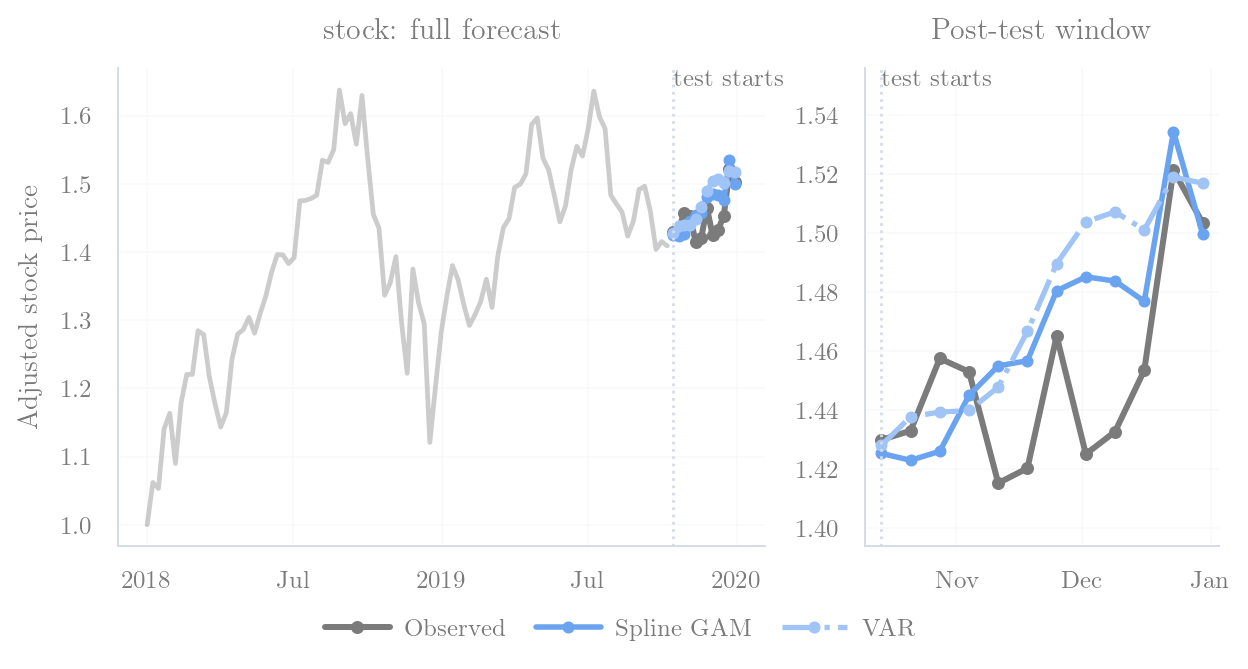

saved: out/gam_finance_forecasting/gam_finance_forecast_panels.pdf


PosixPath('out/gam_finance_forecasting/gam_finance_forecast_panels.pdf')

In [6]:
show_and_save("forecast_panels")


## 5. Zoomed Prediction Window

For lecture notes it is often easier to compare the models on a tighter time window around the forecast horizon. This second version keeps only the last few observed weeks before the split, so the differences between the spline GAM and the VAR reference are easier to see.


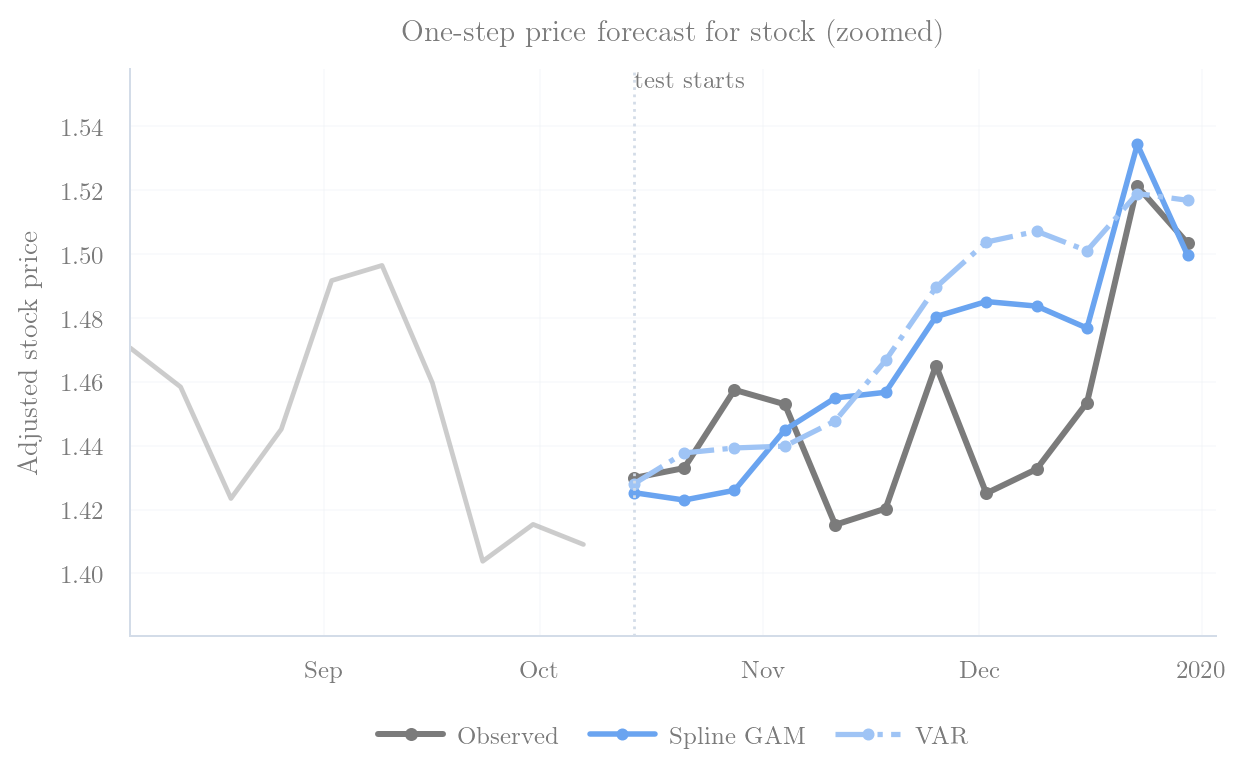

saved: out/gam_finance_forecasting/gam_finance_forecast_zoom.pdf


PosixPath('out/gam_finance_forecasting/gam_finance_forecast_zoom.pdf')

In [7]:
show_and_save("forecast_zoom")


## 6. Smooth Effects Of Lagged Returns

This is the most GAM-specific figure. Each panel varies one lagged return while holding the others at a typical value.

The gray points show training observations. The solid blue line is the spline GAM marginal effect. When the curve bends, the additive model is using a nonlinear feature effect rather than a straight-line response.


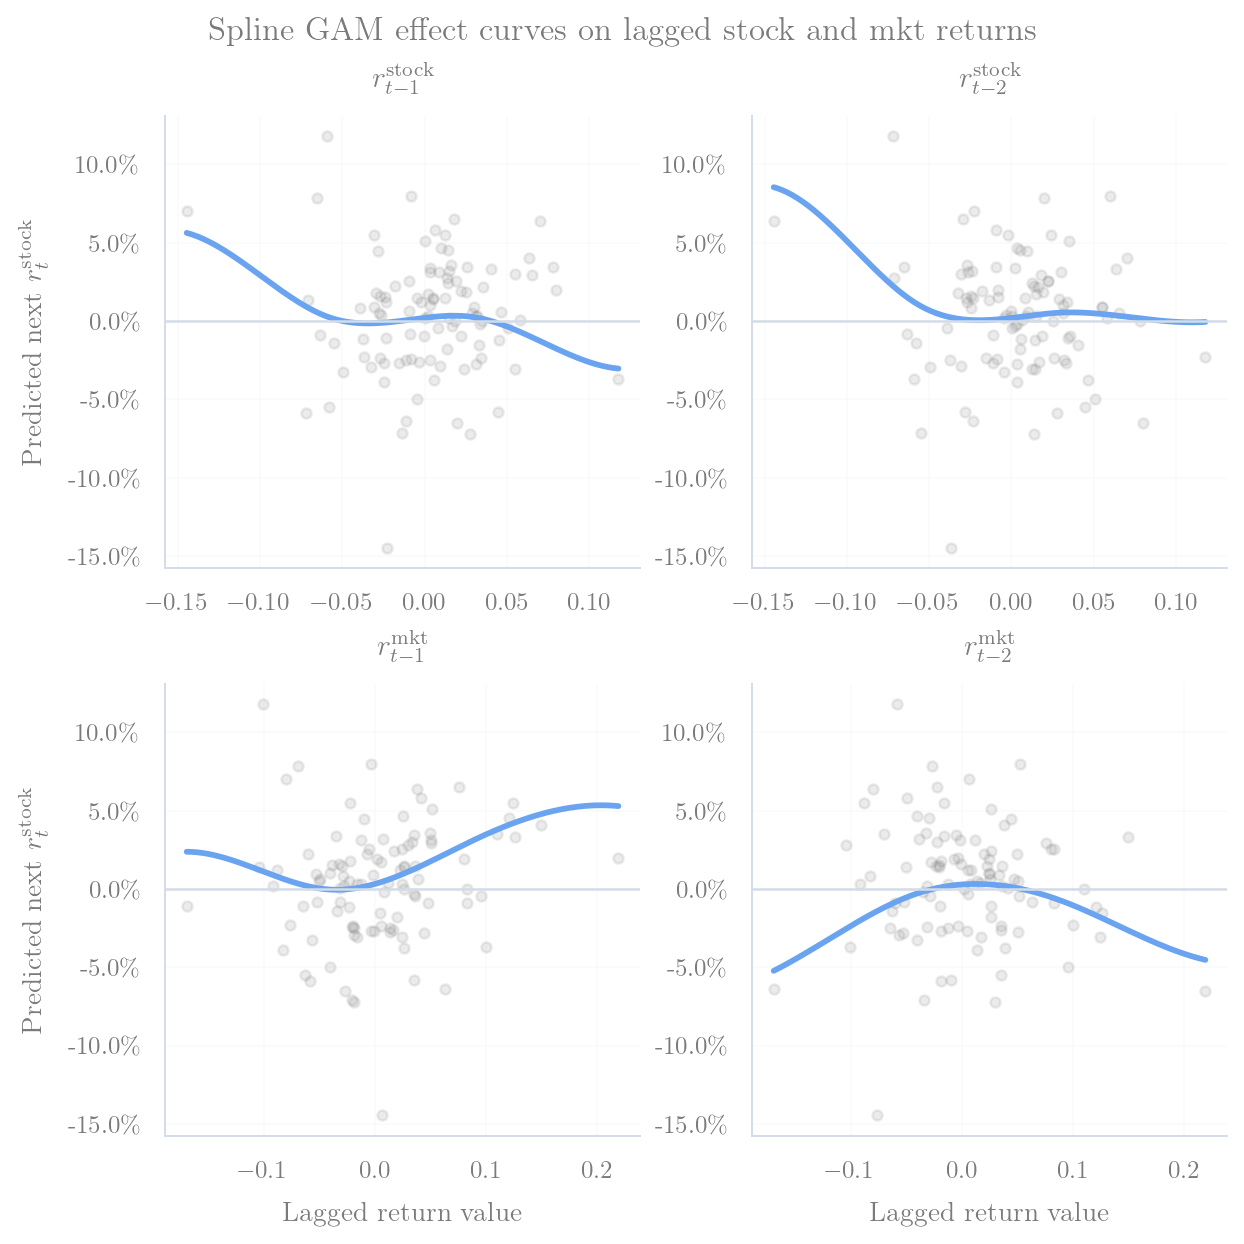

saved: out/gam_finance_forecasting/gam_finance_feature_effects.pdf


PosixPath('out/gam_finance_forecasting/gam_finance_feature_effects.pdf')

In [8]:
show_and_save("feature_effects")


## 7. One Forecast As Additive Parts

Because the GAM is additive, one forecast can still be decomposed into simple parts:

$\text{forecast} = \text{intercept} + \text{stock lag effects} + \text{mkt lag effects}$

The final chart breaks one weekly forecast into exactly those contributions.


saved: out/gam_finance_forecasting/gam_finance_metrics.csv
saved: out/gam_finance_forecasting/gam_finance_validation_search.csv
saved: out/gam_finance_forecasting/gam_finance_prediction_breakdown.csv
saved: out/gam_finance_forecasting/gam_finance_var_prediction_breakdown.csv


,contribution
term,
Intercept,-0.000749
$r_{t-1}^{\mathrm{stock}}$,-0.006542
$r_{t-2}^{\mathrm{stock}}$,-0.024950
$r_{t-1}^{\mathrm{mkt}}$,-0.012234
$r_{t-2}^{\mathrm{mkt}}$,0.045691
Prediction,0.001216


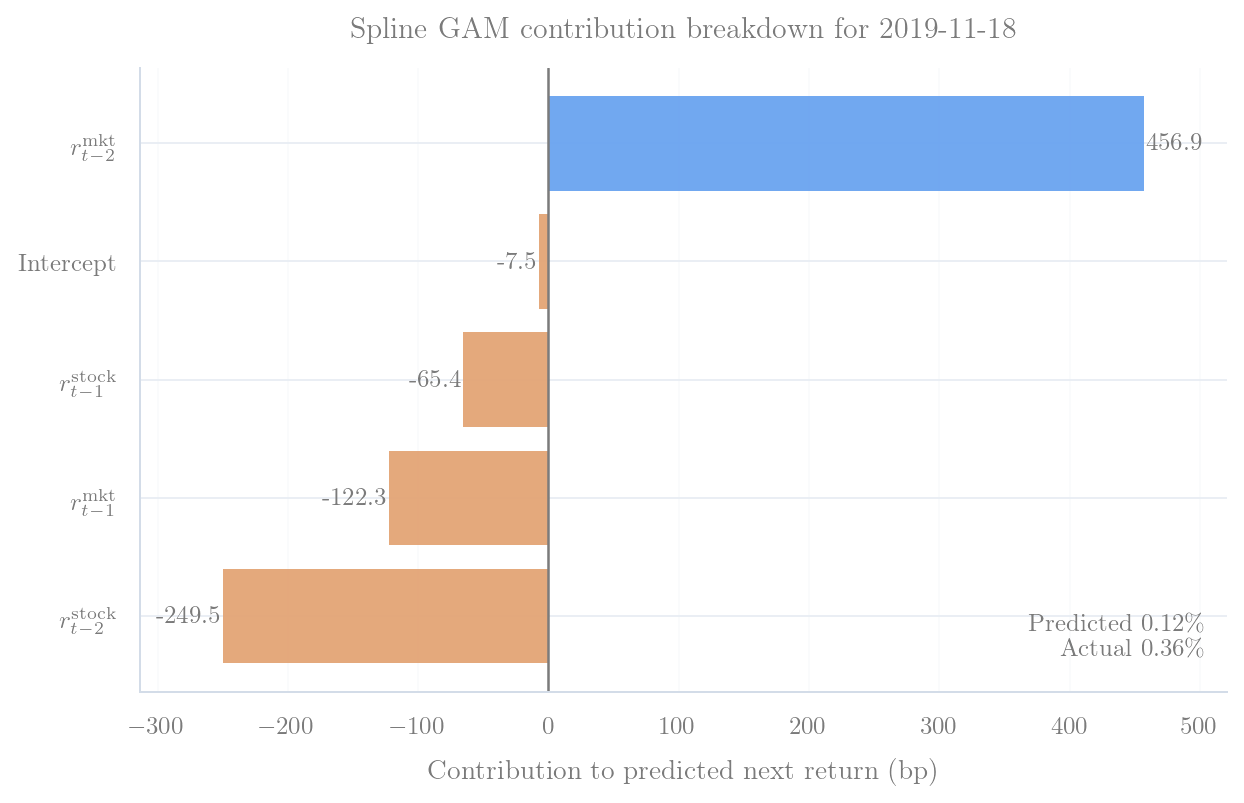

saved: out/gam_finance_forecasting/gam_finance_prediction_breakdown.pdf


,contribution
term,
Intercept,0.003499
$r_{t-1}^{\mathrm{stock}}$,0.003029
$r_{t-1}^{\mathrm{mkt}}$,0.001347
$r_{t-2}^{\mathrm{stock}}$,0.000489
$r_{t-2}^{\mathrm{mkt}}$,0.001387
$r_{t-3}^{\mathrm{stock}}$,-0.002271
$r_{t-3}^{\mathrm{mkt}}$,0.003109
$r_{t-4}^{\mathrm{stock}}$,0.000015
$r_{t-4}^{\mathrm{mkt}}$,-0.000019


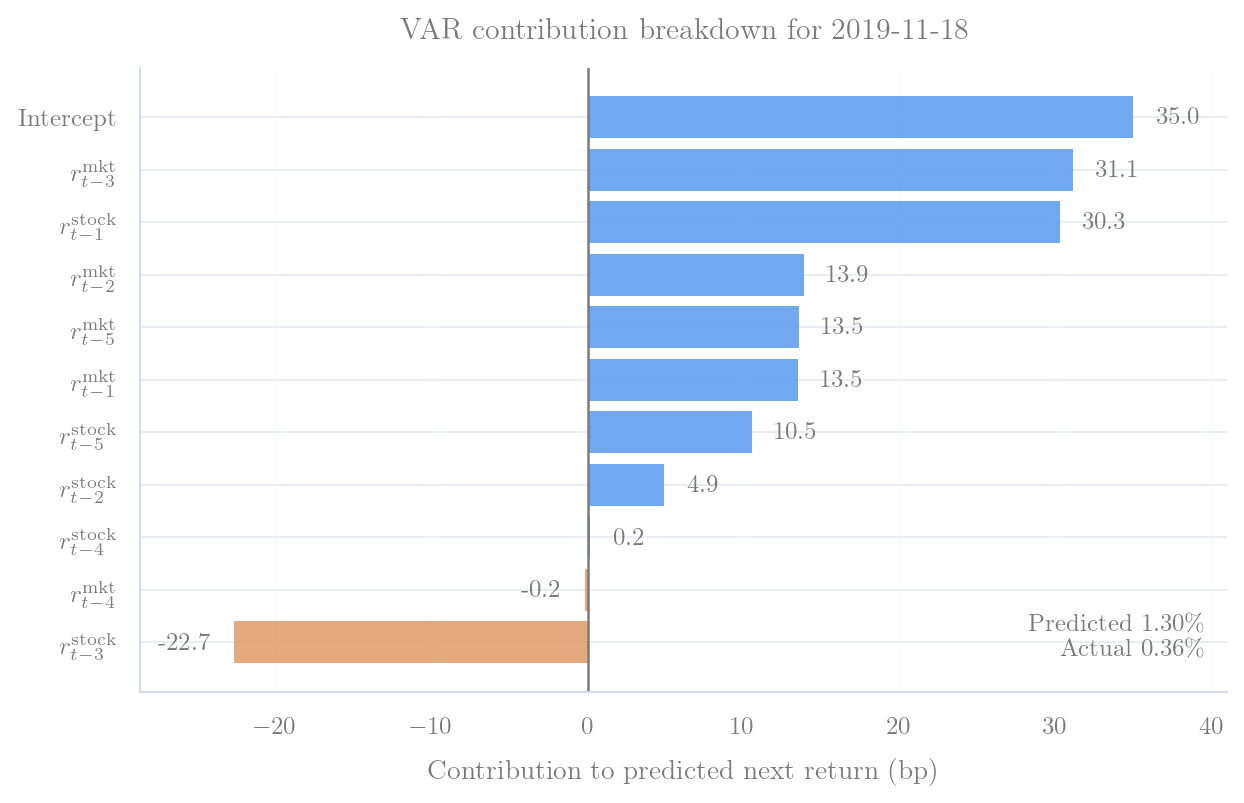

saved: out/gam_finance_forecasting/gam_finance_var_prediction_breakdown.pdf


PosixPath('out/gam_finance_forecasting/gam_finance_var_prediction_breakdown.pdf')

In [9]:
save_table(metrics, f"{FINANCE_GAM_TABLE_FILENAMES['metrics']}.csv")
save_table(search_table, f"{FINANCE_GAM_TABLE_FILENAMES['validation_search']}.csv")
save_table(gam_breakdown_table, f"{FINANCE_GAM_TABLE_FILENAMES['prediction_breakdown']}.csv")
save_table(var_breakdown_table, f"{FINANCE_GAM_TABLE_FILENAMES['var_prediction_breakdown']}.csv")

display(gam_breakdown_table)
show_and_save("prediction_breakdown")

display(var_breakdown_table)
show_and_save("var_prediction_breakdown")
